# 🚀 Startup Success Prediction — Full ML Pipeline
**Dataset:** 100,000 startup records  
**Targets:** Outcome Classification | Revenue | Burn Rate Risk | Funding Rounds | Acquisition Likelihood | IPO Score | Valuation | Investor Risk Score

---

## 📦 1. Install & Import Libraries

In [2]:
# Install required libraries (run once)
!pip install xgboost lightgbm shap scikit-learn pandas numpy matplotlib seaborn joblib

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    mean_absolute_error, r2_score, mean_squared_error,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance

# Boosting
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

# SHAP for explainability
import shap

import joblib

# Style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ All libraries loaded successfully!')

Defaulting to user installation because normal site-packages is not writeable
✅ All libraries loaded successfully!


## 📂 2. Load & Explore Data

In [3]:
df = pd.read_csv('startup_data.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Shape: (100000, 11)

Columns: ['funding_rounds', 'founder_experience_years', 'team_size', 'market_size_billion', 'product_traction_users', 'burn_rate_million', 'revenue_million', 'investor_type', 'sector', 'founder_background', 'outcome']


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


In [4]:
# Summary statistics
display(df.describe())
print('\nNull values:\n', df.isnull().sum())
print('\nOutcome Distribution:\n', df['outcome'].value_counts())

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,2.002300,12.024300,150.732000,33.203875,285422.832730,16.776213,7.828191e+05
std,1.414671,7.208089,86.272631,43.034753,159323.885405,15.711368,6.085069e+05
min,0.000000,0.000000,2.000000,0.288738,668.000000,0.279763,1.344810e+03
25%,1.000000,6.000000,76.000000,10.196778,161194.750000,7.087591,3.154861e+05
50%,2.000000,12.000000,151.000000,20.158063,264989.500000,12.169059,6.213624e+05
75%,3.000000,18.000000,226.000000,39.531967,389214.000000,20.953561,1.098921e+06
max,8.000000,24.000000,299.000000,1072.434476,915203.000000,357.491454,4.168443e+06



Null values:
 funding_rounds              0
founder_experience_years    0
team_size                   0
market_size_billion         0
product_traction_users      0
burn_rate_million           0
revenue_million             0
investor_type               0
sector                      0
founder_background          0
outcome                     0
dtype: int64

Outcome Distribution:
 outcome
Failure        55610
Acquisition    42335
IPO             2055
Name: count, dtype: int64


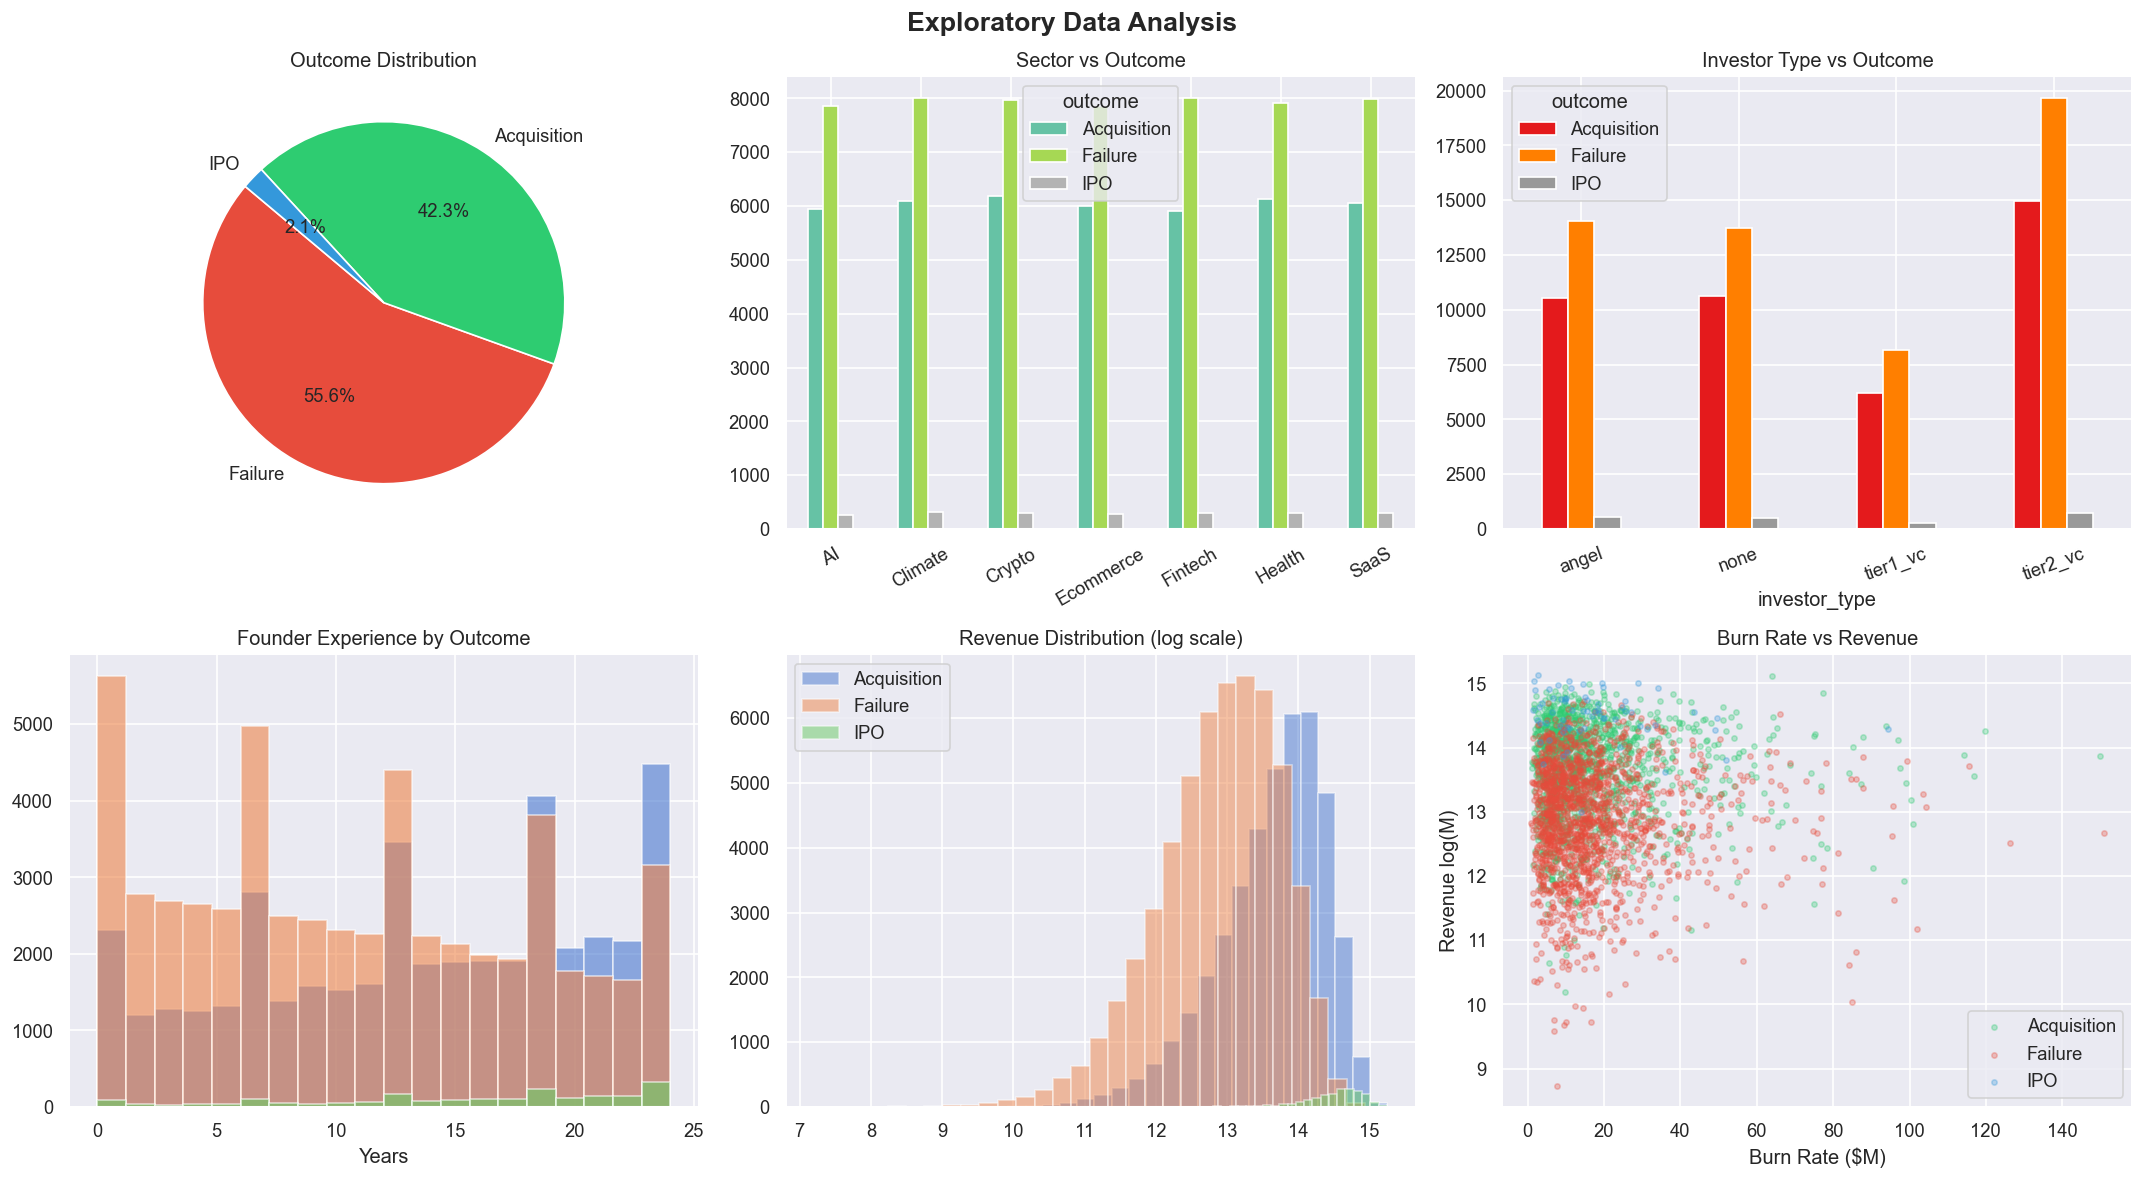

In [5]:
# ── EDA Visualizations ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Outcome distribution
outcome_counts = df['outcome'].value_counts()
colors_pie = ['#e74c3c', '#2ecc71', '#3498db']
axes[0,0].pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%',
              colors=colors_pie, startangle=140)
axes[0,0].set_title('Outcome Distribution')

# Sector vs Outcome
sector_outcome = df.groupby(['sector','outcome']).size().unstack(fill_value=0)
sector_outcome.plot(kind='bar', ax=axes[0,1], colormap='Set2', edgecolor='white')
axes[0,1].set_title('Sector vs Outcome')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=30)

# Investor type vs Outcome
inv_outcome = df.groupby(['investor_type','outcome']).size().unstack(fill_value=0)
inv_outcome.plot(kind='bar', ax=axes[0,2], colormap='Set1', edgecolor='white')
axes[0,2].set_title('Investor Type vs Outcome')
axes[0,2].tick_params(axis='x', rotation=20)

# Founder Experience distribution
df.groupby('outcome')['founder_experience_years'].hist(ax=axes[1,0], alpha=0.6, bins=20, label=df['outcome'].unique())
axes[1,0].set_title('Founder Experience by Outcome')
axes[1,0].set_xlabel('Years')

# Revenue distribution (log scale)
for oc, grp in df.groupby('outcome'):
    axes[1,1].hist(np.log1p(grp['revenue_million']), bins=30, alpha=0.5, label=oc)
axes[1,1].set_title('Revenue Distribution (log scale)')
axes[1,1].legend()

# Burn Rate vs Revenue scatter
sample = df.sample(3000, random_state=42)
color_map = {'Failure':'#e74c3c', 'Acquisition':'#2ecc71', 'IPO':'#3498db'}
for oc, grp in sample.groupby('outcome'):
    axes[1,2].scatter(grp['burn_rate_million'], np.log1p(grp['revenue_million']),
                      alpha=0.3, s=10, label=oc, color=color_map[oc])
axes[1,2].set_xlabel('Burn Rate ($M)')
axes[1,2].set_ylabel('Revenue log(M)')
axes[1,2].set_title('Burn Rate vs Revenue')
axes[1,2].legend()

plt.tight_layout()
plt.show()

## 🔧 3. Feature Engineering & Preprocessing

In [6]:
df_fe = df.copy()

# --- Derived Features ---
df_fe['revenue_per_employee']    = df_fe['revenue_million'] / (df_fe['team_size'] + 1)
df_fe['burn_efficiency']         = df_fe['revenue_million'] / (df_fe['burn_rate_million'] + 0.01)
df_fe['traction_per_employee']   = df_fe['product_traction_users'] / (df_fe['team_size'] + 1)
df_fe['market_penetration']      = df_fe['product_traction_users'] / (df_fe['market_size_billion'] * 1e6 + 1)
df_fe['funding_per_round']       = df_fe['burn_rate_million'] * 12 / (df_fe['funding_rounds'] + 1)
df_fe['exp_team_ratio']          = df_fe['founder_experience_years'] / (df_fe['team_size'] + 1)
df_fe['revenue_to_market']       = df_fe['revenue_million'] / (df_fe['market_size_billion'] * 1e6 + 1)
df_fe['log_revenue']             = np.log1p(df_fe['revenue_million'])
df_fe['log_traction']            = np.log1p(df_fe['product_traction_users'])

# --- Valuation Estimate (simplified VC rule-of-thumb: Revenue × multiple)
MULTIPLE_MAP = {'none': 3, 'angel': 5, 'tier2_vc': 8, 'tier1_vc': 15}
df_fe['valuation_estimate_M'] = df_fe.apply(
    lambda r: (r['revenue_million'] / 1e6) * MULTIPLE_MAP.get(r['investor_type'], 5), axis=1
)

# --- Categorical Encoding ---
cat_cols = ['investor_type', 'sector', 'founder_background']
le_dict = {}
for c in cat_cols:
    le = LabelEncoder()
    df_fe[c + '_enc'] = le.fit_transform(df_fe[c])
    le_dict[c] = le

# Outcome encoding
le_outcome = LabelEncoder()
df_fe['outcome_enc'] = le_outcome.fit_transform(df_fe['outcome'])  # 0=Acquisition,1=Failure,2=IPO

print('Outcome classes:', list(le_outcome.classes_))
print('✅ Feature engineering done. Shape:', df_fe.shape)

Outcome classes: ['Acquisition', 'Failure', 'IPO']
✅ Feature engineering done. Shape: (100000, 25)


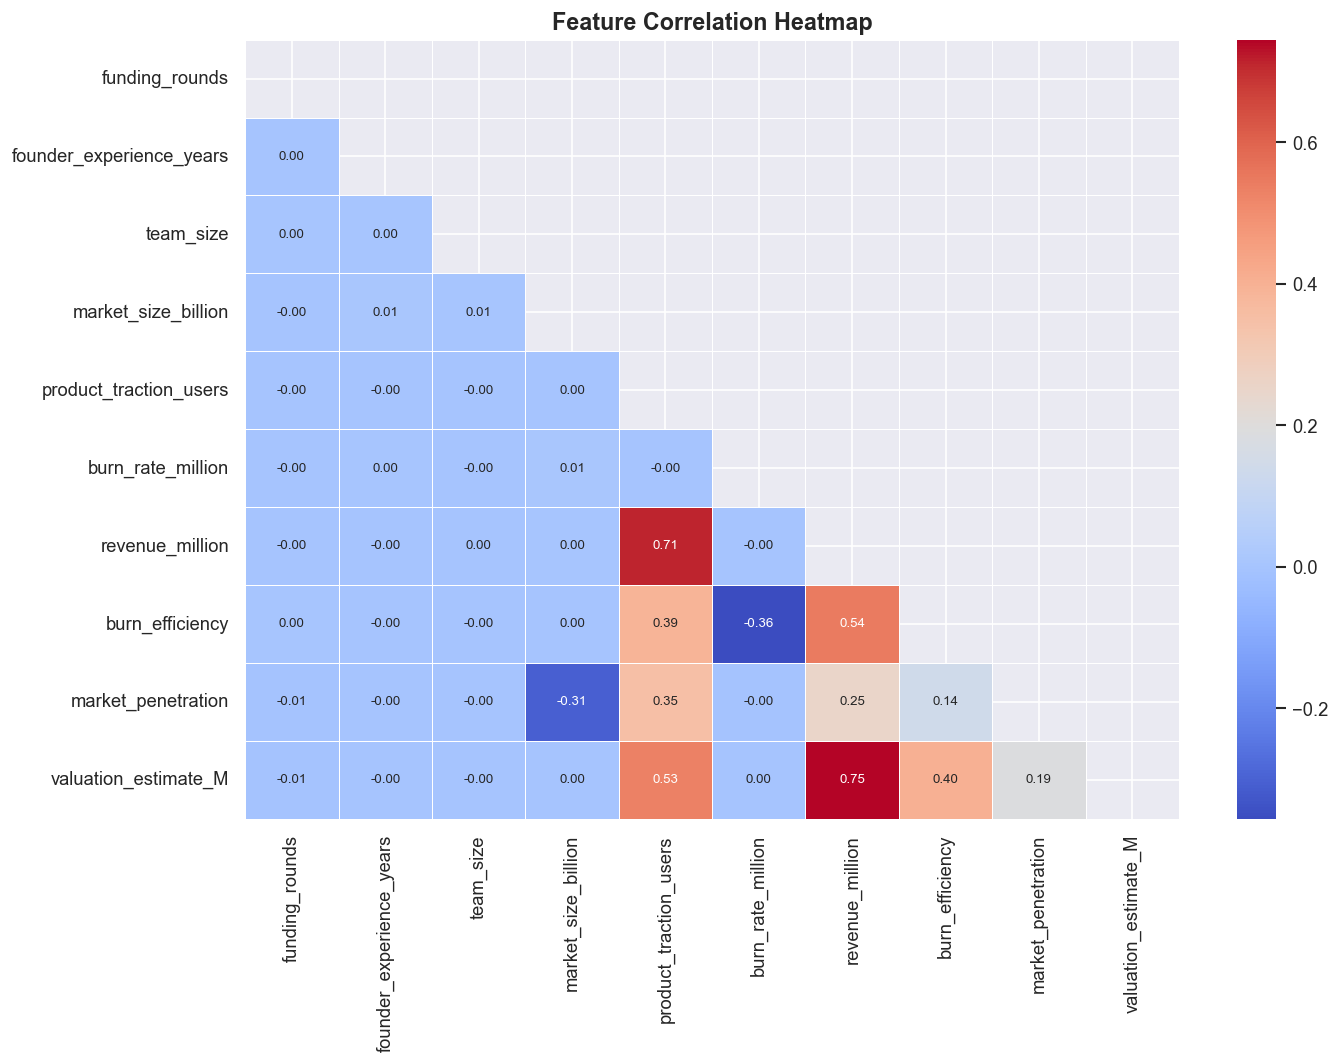

In [7]:
# Correlation heatmap of numeric features
num_cols = ['funding_rounds','founder_experience_years','team_size','market_size_billion',
            'product_traction_users','burn_rate_million','revenue_million',
            'burn_efficiency','market_penetration','valuation_estimate_M']

fig, ax = plt.subplots(figsize=(12, 9))
corr = df_fe[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# --- Define feature sets ---
BASE_FEATURES = [
    'funding_rounds', 'founder_experience_years', 'team_size',
    'market_size_billion', 'product_traction_users', 'burn_rate_million',
    'revenue_million', 'investor_type_enc', 'sector_enc', 'founder_background_enc',
    'revenue_per_employee', 'burn_efficiency', 'traction_per_employee',
    'market_penetration', 'funding_per_round', 'exp_team_ratio',
    'revenue_to_market', 'log_revenue', 'log_traction'
]

X = df_fe[BASE_FEATURES]
y_outcome   = df_fe['outcome_enc']
y_revenue   = df_fe['log_revenue']
y_burn_risk = (df_fe['burn_rate_million'] > df_fe['burn_rate_million'].quantile(0.75)).astype(int)  # High burn = 1
y_fund_rounds = df_fe['funding_rounds']
y_valuation   = np.log1p(df_fe['valuation_estimate_M'])

# Acquisition likelihood (binary)
y_acquisition = (df_fe['outcome'] == 'Acquisition').astype(int)
# IPO potential (binary)
y_ipo = (df_fe['outcome'] == 'IPO').astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splits
X_tr, X_te, yo_tr, yo_te = train_test_split(X_scaled, y_outcome, test_size=0.2, random_state=42, stratify=y_outcome)
X_tr_r, X_te_r, yr_tr, yr_te = train_test_split(X_scaled, y_revenue, test_size=0.2, random_state=42)
X_tr_b, X_te_b, yb_tr, yb_te = train_test_split(X_scaled, y_burn_risk, test_size=0.2, random_state=42)
X_tr_f, X_te_f, yf_tr, yf_te = train_test_split(X_scaled, y_fund_rounds, test_size=0.2, random_state=42)
X_tr_a, X_te_a, ya_tr, ya_te = train_test_split(X_scaled, y_acquisition, test_size=0.2, random_state=42)
X_tr_i, X_te_i, yi_tr, yi_te = train_test_split(X_scaled, y_ipo, test_size=0.2, random_state=42)
X_tr_v, X_te_v, yv_tr, yv_te = train_test_split(X_scaled, y_valuation, test_size=0.2, random_state=42)

print('✅ Train/test splits ready')

✅ Train/test splits ready


## 🎯 4. Task 1 — Predicted Outcome + Probability (Multi-class)

In [9]:
print('Training Outcome Classifiers...\n')

outcome_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, C=1.0, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                         use_label_encoder=False, eval_metric='mlogloss',
                                         random_state=42, n_jobs=-1),
    'LightGBM':            LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                          num_leaves=63, random_state=42, n_jobs=-1, verbose=-1)
}

outcome_results = {}
for name, model in outcome_models.items():
    model.fit(X_tr, yo_tr)
    preds   = model.predict(X_te)
    proba   = model.predict_proba(X_te)
    roc_ovr = roc_auc_score(yo_te, proba, multi_class='ovr', average='macro')
    outcome_results[name] = {'model': model, 'preds': preds, 'proba': proba, 'roc_auc': roc_ovr}
    print(f'{name:22s} → ROC-AUC (macro OvR): {roc_ovr:.4f}')

# Best model
best_outcome_name = max(outcome_results, key=lambda k: outcome_results[k]['roc_auc'])
best_outcome_model = outcome_results[best_outcome_name]['model']
print(f'\n🏆 Best Outcome Model: {best_outcome_name}')

Training Outcome Classifiers...

Logistic Regression    → ROC-AUC (macro OvR): 0.8715
Random Forest          → ROC-AUC (macro OvR): 0.8661
XGBoost                → ROC-AUC (macro OvR): 0.8672
LightGBM               → ROC-AUC (macro OvR): 0.8666

🏆 Best Outcome Model: Logistic Regression


In [10]:
# Classification report for best model
best_preds = outcome_results[best_outcome_name]['preds']
print(f'Classification Report — {best_outcome_name}\n')
print(classification_report(yo_te, best_preds, target_names=le_outcome.classes_))

Classification Report — Logistic Regression

              precision    recall  f1-score   support

 Acquisition       0.72      0.66      0.69      8467
     Failure       0.76      0.83      0.79     11122
         IPO       0.66      0.27      0.38       411

    accuracy                           0.74     20000
   macro avg       0.71      0.58      0.62     20000
weighted avg       0.74      0.74      0.74     20000



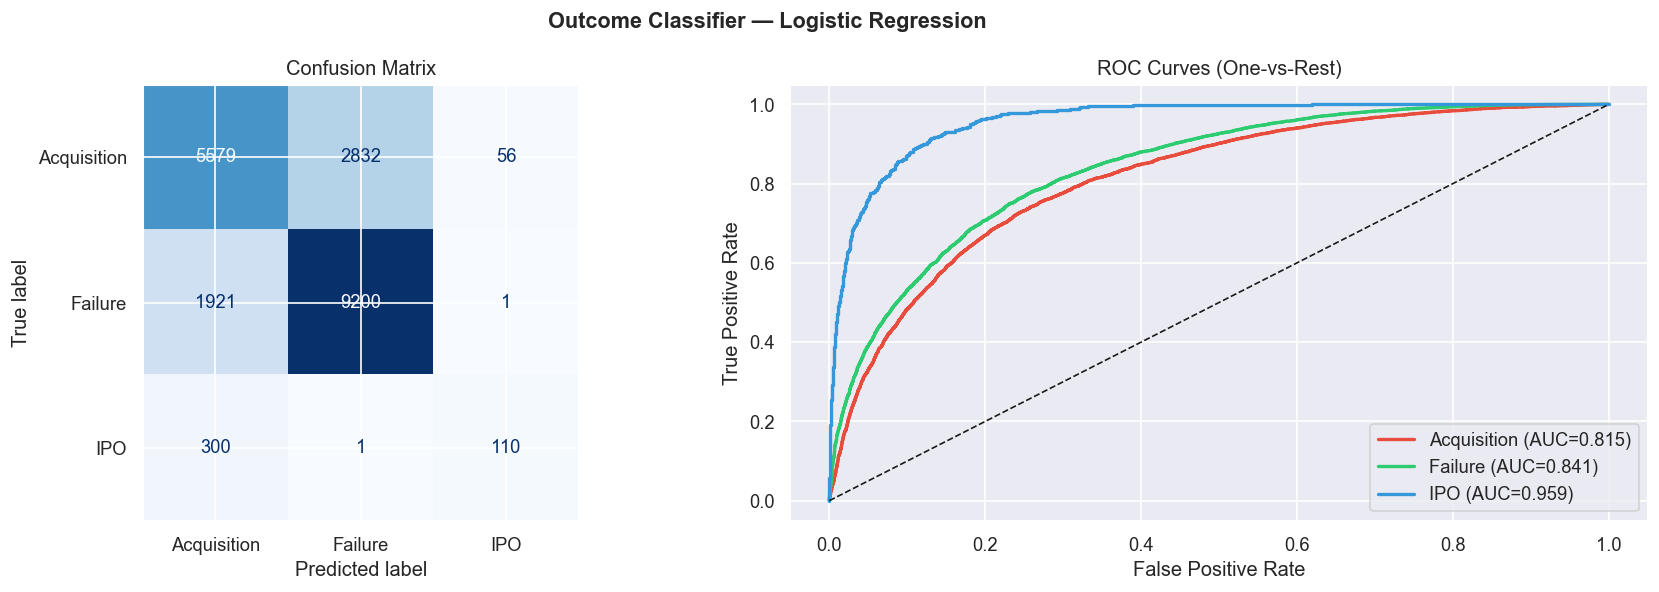

In [11]:
# Confusion Matrix + ROC curves side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Outcome Classifier — {best_outcome_name}', fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(yo_te, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_outcome.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC curves (OvR)
y_bin = label_binarize(yo_te, classes=[0, 1, 2])
proba = outcome_results[best_outcome_name]['proba']
colors_roc = ['#e74c3c', '#2ecc71', '#3498db']
for i, (cls, col) in enumerate(zip(le_outcome.classes_, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
    roc_auc_i = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={roc_auc_i:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (One-vs-Rest)')
axes[1].legend()
plt.tight_layout()
plt.show()

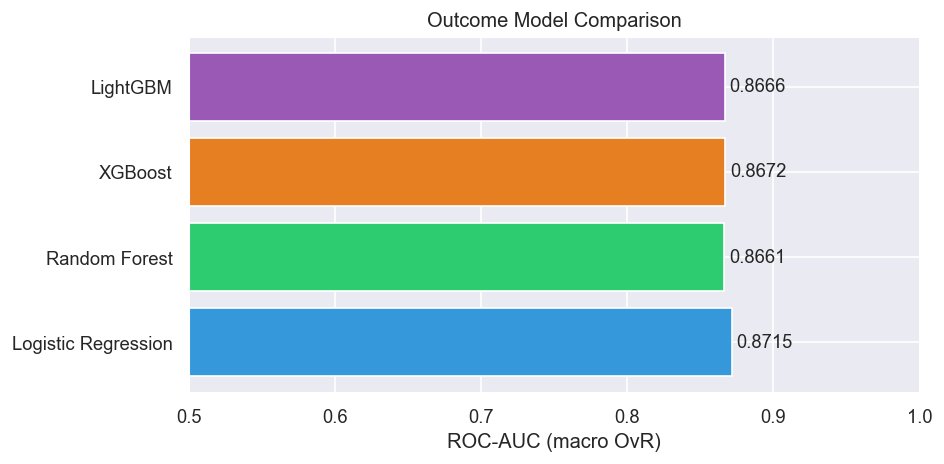

In [12]:
# Model comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))
names  = list(outcome_results.keys())
scores = [outcome_results[n]['roc_auc'] for n in names]
bars = ax.barh(names, scores, color=['#3498db','#2ecc71','#e67e22','#9b59b6'], edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('ROC-AUC (macro OvR)')
ax.set_title('Outcome Model Comparison')
plt.tight_layout()
plt.show()

## 💰 5. Task 2 — Revenue Prediction

In [13]:
print('Training Revenue Regressors...\n')

rev_models = {
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                      random_state=42, n_jobs=-1),
    'LightGBM':          LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                       num_leaves=63, random_state=42, n_jobs=-1, verbose=-1)
}

rev_results = {}
for name, model in rev_models.items():
    model.fit(X_tr_r, yr_tr)
    preds = model.predict(X_te_r)
    mae   = mean_absolute_error(yr_te, preds)
    r2    = r2_score(yr_te, preds)
    rmse  = np.sqrt(mean_squared_error(yr_te, preds))
    rev_results[name] = {'model': model, 'preds': preds, 'mae': mae, 'r2': r2, 'rmse': rmse}
    print(f'{name:22s} → MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')

best_rev_name  = max(rev_results, key=lambda k: rev_results[k]['r2'])
best_rev_model = rev_results[best_rev_name]['model']
print(f'\n🏆 Best Revenue Model: {best_rev_name}')

Training Revenue Regressors...

Ridge Regression       → MAE=0.0000  RMSE=0.0000  R²=1.0000
Random Forest          → MAE=0.0001  RMSE=0.0015  R²=1.0000
XGBoost                → MAE=0.0054  RMSE=0.0217  R²=0.9995
LightGBM               → MAE=0.0043  RMSE=0.0221  R²=0.9994

🏆 Best Revenue Model: Ridge Regression


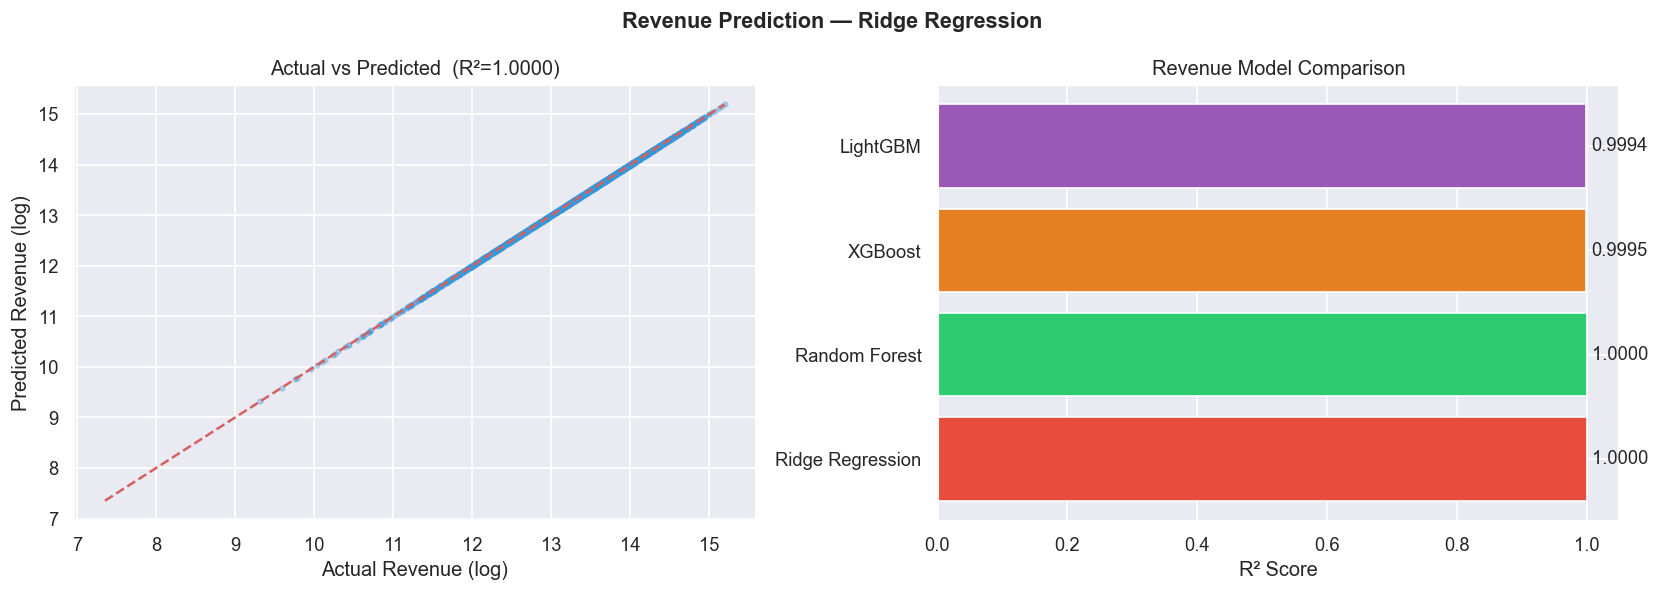

In [14]:
# Revenue prediction plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Revenue Prediction — {best_rev_name}', fontsize=13, fontweight='bold')

bp = rev_results[best_rev_name]['preds']
sample_idx = np.random.choice(len(yr_te), 2000, replace=False)
axes[0].scatter(yr_te.values[sample_idx], bp[sample_idx], alpha=0.3, s=8, color='#3498db')
mn, mx = yr_te.min(), yr_te.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
axes[0].set_xlabel('Actual Revenue (log)')
axes[0].set_ylabel('Predicted Revenue (log)')
axes[0].set_title(f'Actual vs Predicted  (R²={rev_results[best_rev_name]["r2"]:.4f})')

# Model comparison
rev_r2 = {n: rev_results[n]['r2'] for n in rev_results}
bars = axes[1].barh(list(rev_r2.keys()), list(rev_r2.values()),
                    color=['#e74c3c','#2ecc71','#e67e22','#9b59b6'], edgecolor='white')
axes[1].bar_label(bars, fmt='%.4f', padding=3)
axes[1].set_xlabel('R² Score')
axes[1].set_title('Revenue Model Comparison')
plt.tight_layout()
plt.show()

## 🔥 6. Task 3 — Burn Rate Risk Prediction

In [15]:
print('Training Burn Rate Risk Classifiers (High Burn = top 25%)...\n')

burn_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                         use_label_encoder=False, eval_metric='logloss',
                                         random_state=42, n_jobs=-1),
    'LightGBM':            LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                          num_leaves=63, random_state=42, n_jobs=-1, verbose=-1)
}

burn_results = {}
for name, model in burn_models.items():
    model.fit(X_tr_b, yb_tr)
    preds = model.predict(X_te_b)
    proba = model.predict_proba(X_te_b)[:, 1]
    roc   = roc_auc_score(yb_te, proba)
    burn_results[name] = {'model': model, 'preds': preds, 'proba': proba, 'roc_auc': roc}
    print(f'{name:22s} → ROC-AUC: {roc:.4f}')

best_burn_name  = max(burn_results, key=lambda k: burn_results[k]['roc_auc'])
best_burn_model = burn_results[best_burn_name]['model']
print(f'\n🏆 Best Burn Risk Model: {best_burn_name}')

Training Burn Rate Risk Classifiers (High Burn = top 25%)...

Logistic Regression    → ROC-AUC: 1.0000
Random Forest          → ROC-AUC: 1.0000
XGBoost                → ROC-AUC: 1.0000
LightGBM               → ROC-AUC: 1.0000

🏆 Best Burn Risk Model: Random Forest


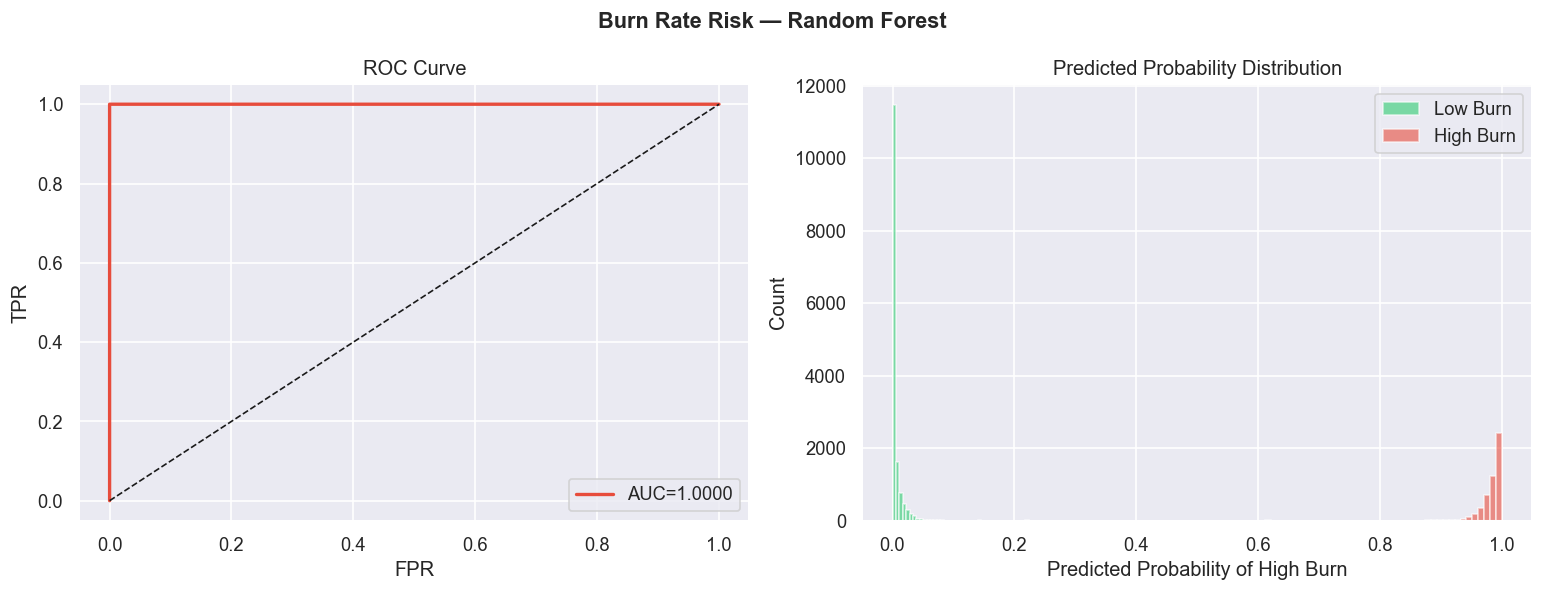

In [16]:
# Burn risk ROC + probability histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Burn Rate Risk — {best_burn_name}', fontsize=13, fontweight='bold')

fpr, tpr, _ = roc_curve(yb_te, burn_results[best_burn_name]['proba'])
roc_val = burn_results[best_burn_name]['roc_auc']
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC={roc_val:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve')
axes[0].legend()

proba_vals = burn_results[best_burn_name]['proba']
axes[1].hist(proba_vals[yb_te==0], bins=40, alpha=0.6, color='#2ecc71', label='Low Burn')
axes[1].hist(proba_vals[yb_te==1], bins=40, alpha=0.6, color='#e74c3c', label='High Burn')
axes[1].set_xlabel('Predicted Probability of High Burn')
axes[1].set_ylabel('Count')
axes[1].set_title('Predicted Probability Distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

## 🔢 7. Task 4 — Predict Number of Funding Rounds

In [17]:
# Funding rounds as regression
print('Training Funding Rounds Regressors...\n')

fund_models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest':    RandomForestRegressor(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42),
    'XGBoost':          XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                     random_state=42, n_jobs=-1),
    'LightGBM':         LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                      num_leaves=63, random_state=42, n_jobs=-1, verbose=-1)
}

fund_results = {}
for name, model in fund_models.items():
    model.fit(X_tr_f, yf_tr)
    preds = model.predict(X_te_f)
    preds_clipped = np.clip(np.round(preds), 1, None)  # at least 1 round
    mae  = mean_absolute_error(yf_te, preds_clipped)
    r2   = r2_score(yf_te, preds_clipped)
    fund_results[name] = {'model': model, 'preds': preds_clipped, 'mae': mae, 'r2': r2}
    print(f'{name:22s} → MAE={mae:.3f}  R²={r2:.4f}')

best_fund_name  = max(fund_results, key=lambda k: fund_results[k]['r2'])
best_fund_model = fund_results[best_fund_name]['model']
print(f'\n🏆 Best Funding Rounds Model: {best_fund_name}')

Training Funding Rounds Regressors...

Ridge Regression       → MAE=0.136  R²=0.9332
Random Forest          → MAE=0.136  R²=0.9332
XGBoost                → MAE=0.136  R²=0.9332
LightGBM               → MAE=0.136  R²=0.9332

🏆 Best Funding Rounds Model: Ridge Regression


## 🤝 8. Task 5 — Acquisition Likelihood

In [18]:
print('Training Acquisition Likelihood Models...\n')

acq_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                         use_label_encoder=False, eval_metric='logloss',
                                         random_state=42, n_jobs=-1),
    'LightGBM':            LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                          num_leaves=63, random_state=42, n_jobs=-1, verbose=-1)
}

acq_results = {}
for name, model in acq_models.items():
    model.fit(X_tr_a, ya_tr)
    preds = model.predict(X_te_a)
    proba = model.predict_proba(X_te_a)[:, 1]
    roc   = roc_auc_score(ya_te, proba)
    acq_results[name] = {'model': model, 'preds': preds, 'proba': proba, 'roc_auc': roc}
    print(f'{name:22s} → ROC-AUC: {roc:.4f}')

best_acq_name  = max(acq_results, key=lambda k: acq_results[k]['roc_auc'])
best_acq_model = acq_results[best_acq_name]['model']
print(f'\n🏆 Best Acquisition Model: {best_acq_name}')

Training Acquisition Likelihood Models...

Logistic Regression    → ROC-AUC: 0.8007
Random Forest          → ROC-AUC: 0.8036
XGBoost                → ROC-AUC: 0.8078
LightGBM               → ROC-AUC: 0.8084

🏆 Best Acquisition Model: LightGBM


## 🏦 9. Task 6 — IPO Potential Score

In [19]:
print('Training IPO Potential Models...\n')

# Note: IPO class is heavily imbalanced (only ~2%), so use scale_pos_weight
ipo_pos_weight = (y_ipo == 0).sum() / (y_ipo == 1).sum()

ipo_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   class_weight='balanced', n_jobs=-1, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                         scale_pos_weight=ipo_pos_weight,
                                         use_label_encoder=False, eval_metric='logloss',
                                         random_state=42, n_jobs=-1),
    'LightGBM':            LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                          is_unbalance=True, num_leaves=63,
                                          random_state=42, n_jobs=-1, verbose=-1)
}

ipo_results = {}
for name, model in ipo_models.items():
    model.fit(X_tr_i, yi_tr)
    preds = model.predict(X_te_i)
    proba = model.predict_proba(X_te_i)[:, 1]
    roc   = roc_auc_score(yi_te, proba)
    ipo_results[name] = {'model': model, 'preds': preds, 'proba': proba, 'roc_auc': roc}
    print(f'{name:22s} → ROC-AUC: {roc:.4f}')

best_ipo_name  = max(ipo_results, key=lambda k: ipo_results[k]['roc_auc'])
best_ipo_model = ipo_results[best_ipo_name]['model']
print(f'\n🏆 Best IPO Model: {best_ipo_name}')

Training IPO Potential Models...

Logistic Regression    → ROC-AUC: 0.9588
Random Forest          → ROC-AUC: 0.9460
XGBoost                → ROC-AUC: 0.9426
LightGBM               → ROC-AUC: 0.9425

🏆 Best IPO Model: Logistic Regression


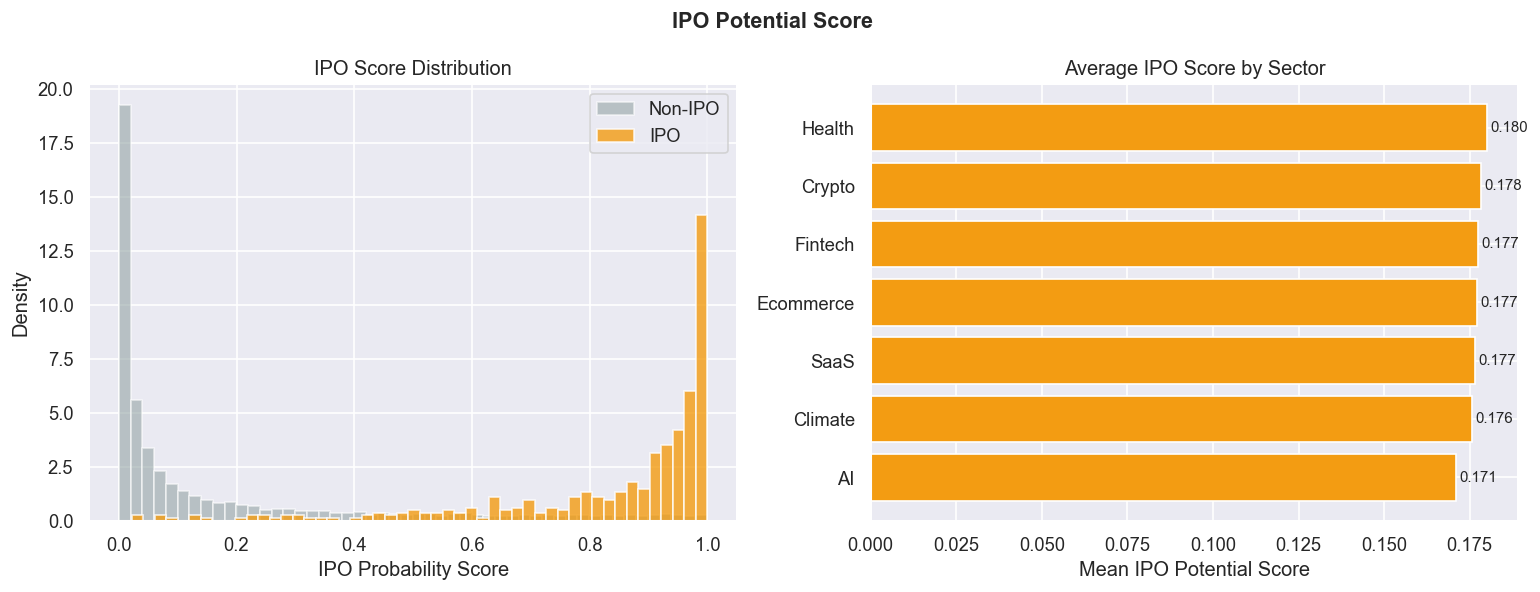

In [20]:
# IPO Score distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('IPO Potential Score', fontsize=13, fontweight='bold')

ipo_proba = ipo_results[best_ipo_name]['proba']
axes[0].hist(ipo_proba[yi_te==0], bins=50, alpha=0.6, color='#95a5a6', label='Non-IPO', density=True)
axes[0].hist(ipo_proba[yi_te==1], bins=50, alpha=0.8, color='#f39c12', label='IPO', density=True)
axes[0].set_xlabel('IPO Probability Score')
axes[0].set_ylabel('Density')
axes[0].set_title('IPO Score Distribution')
axes[0].legend()

# IPO score by sector
df_fe['ipo_score'] = best_ipo_model.predict_proba(X_scaled)[:, 1]
sector_ipo = df_fe.groupby('sector')['ipo_score'].mean().sort_values(ascending=True)
axes[1].barh(sector_ipo.index, sector_ipo.values, color='#f39c12', edgecolor='white')
axes[1].set_xlabel('Mean IPO Potential Score')
axes[1].set_title('Average IPO Score by Sector')
for i, v in enumerate(sector_ipo.values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 📊 10. Task 7 — Feature Importance Analysis Table

In [21]:
# Use LightGBM (best tree model) for feature importance
lgbm_outcome = LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                               num_leaves=63, random_state=42, n_jobs=-1, verbose=-1)
lgbm_outcome.fit(X_tr, yo_tr)

fi_df = pd.DataFrame({
    'Feature':    BASE_FEATURES,
    'Importance': lgbm_outcome.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fi_df['Rank']       = fi_df.index + 1
fi_df['Importance_Norm'] = (fi_df['Importance'] / fi_df['Importance'].sum() * 100).round(2)
fi_df['Cumulative_%']    = fi_df['Importance_Norm'].cumsum().round(2)

print('📋 Feature Importance Analysis Table (LightGBM — Outcome Classifier)')
display(fi_df[['Rank','Feature','Importance','Importance_Norm','Cumulative_%']])

📋 Feature Importance Analysis Table (LightGBM — Outcome Classifier)


,Rank,Feature,Importance,Importance_Norm,Cumulative_%
0,1,founder_experience_years,3476,8.29,8.29
1,2,team_size,3386,8.07,16.36
2,3,revenue_million,3088,7.36,23.72
3,4,funding_rounds,2955,7.04,30.76
4,5,product_traction_users,2923,6.97,37.73
5,6,funding_per_round,2616,6.24,43.97
6,7,burn_rate_million,2556,6.09,50.06
7,8,exp_team_ratio,2501,5.96,56.02
8,9,market_size_billion,2466,5.88,61.90
9,10,burn_efficiency,2406,5.74,67.64


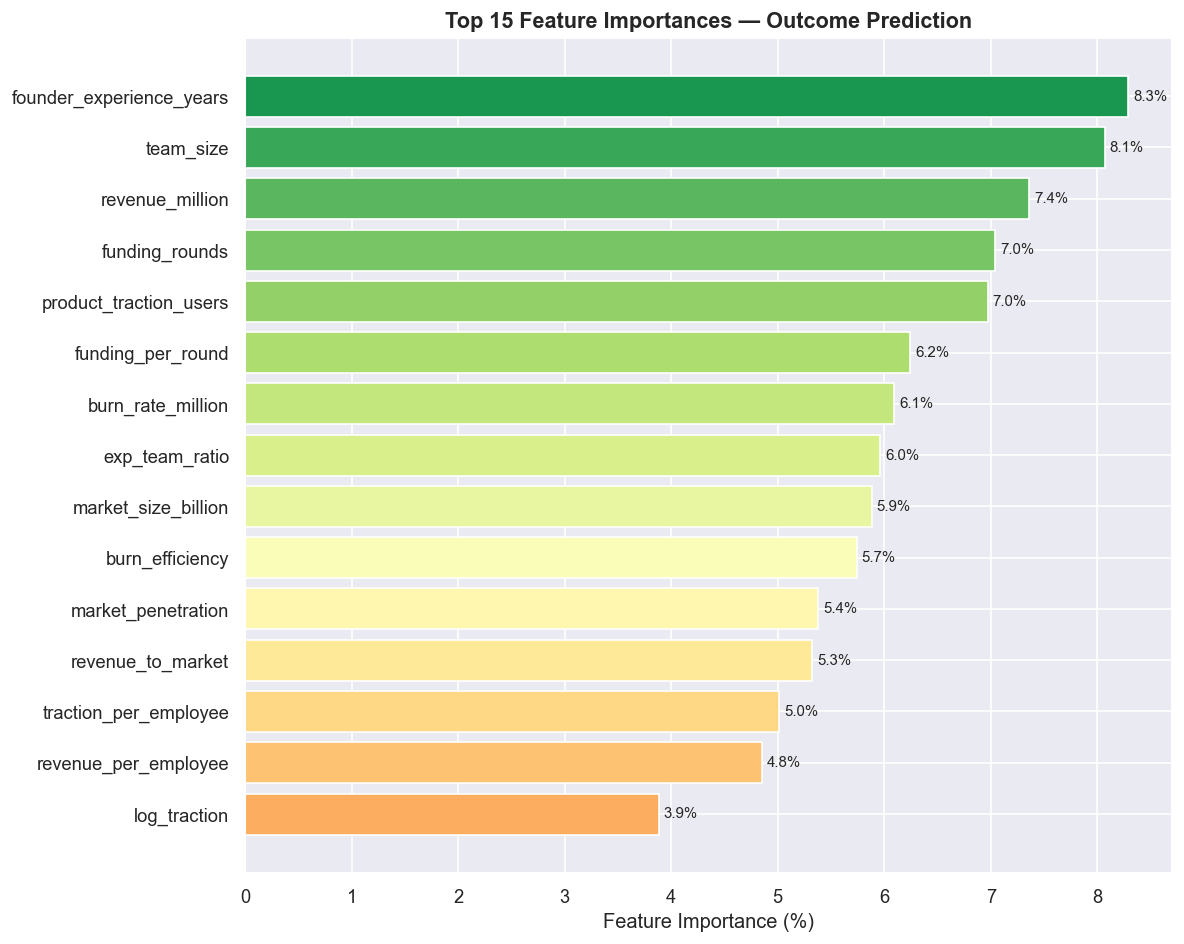

In [22]:
# Feature importance horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))
top_fi = fi_df.head(15)
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_fi)))
bars = ax.barh(top_fi['Feature'][::-1], top_fi['Importance_Norm'][::-1], color=colors_fi, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('Feature Importance (%)')
ax.set_title('Top 15 Feature Importances — Outcome Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Computing SHAP values (this may take ~1 min)...


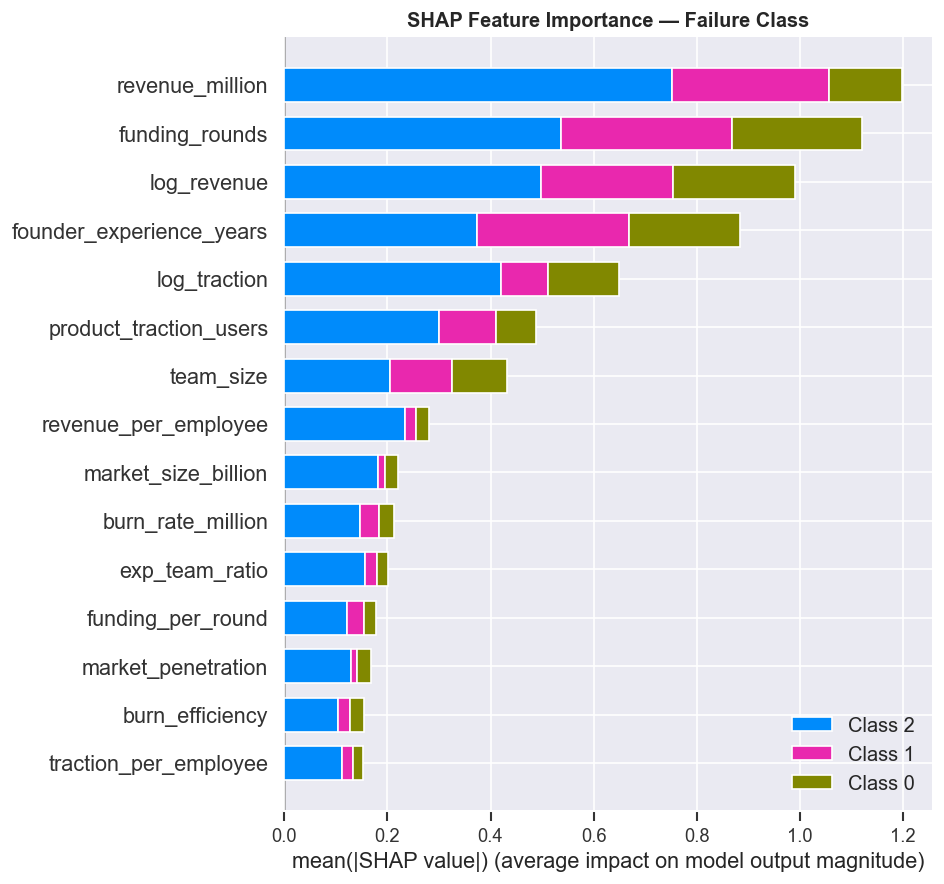

In [23]:
# SHAP Analysis
print('Computing SHAP values (this may take ~1 min)...')
explainer   = shap.TreeExplainer(lgbm_outcome)
X_te_df     = pd.DataFrame(X_te[:2000], columns=BASE_FEATURES)
shap_values = explainer.shap_values(X_te_df)

# SHAP summary plot (use class index 1 = Failure)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_te_df, plot_type='bar',
                  feature_names=BASE_FEATURES, show=False, max_display=15)
plt.title('SHAP Feature Importance — Failure Class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 🏢 11. Task 8 — Startup Valuation Estimation

In [35]:
print('Training Valuation Estimators...\n')

val_models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest':    RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42),
    'XGBoost':          XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                     random_state=42, n_jobs=-1),
    'LightGBM':         LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                      num_leaves=63, random_state=42, n_jobs=-1, verbose=-1)
}

val_results = {}
for name, model in val_models.items():
    model.fit(X_tr_v, yv_tr)
    preds = model.predict(X_te_v)
    mae   = mean_absolute_error(yv_te, preds)
    r2    = r2_score(yv_te, preds)
    val_results[name] = {'model': model, 'preds': preds, 'mae': mae, 'r2': r2}
    print(f'{name:22s} → MAE={mae:.4f}  R²={r2:.4f}')

best_val_name  = max(val_results, key=lambda k: val_results[k]['r2'])
best_val_model = val_results[best_val_name]['model']
print(f'\n🏆 Best Valuation Model: {best_val_name}')

Training Valuation Estimators...

Ridge Regression       → MAE=0.2573  R²=0.7989
Random Forest          → MAE=0.0002  R²=1.0000
XGBoost                → MAE=0.0031  R²=0.9999
LightGBM               → MAE=0.0025  R²=1.0000

🏆 Best Valuation Model: Random Forest


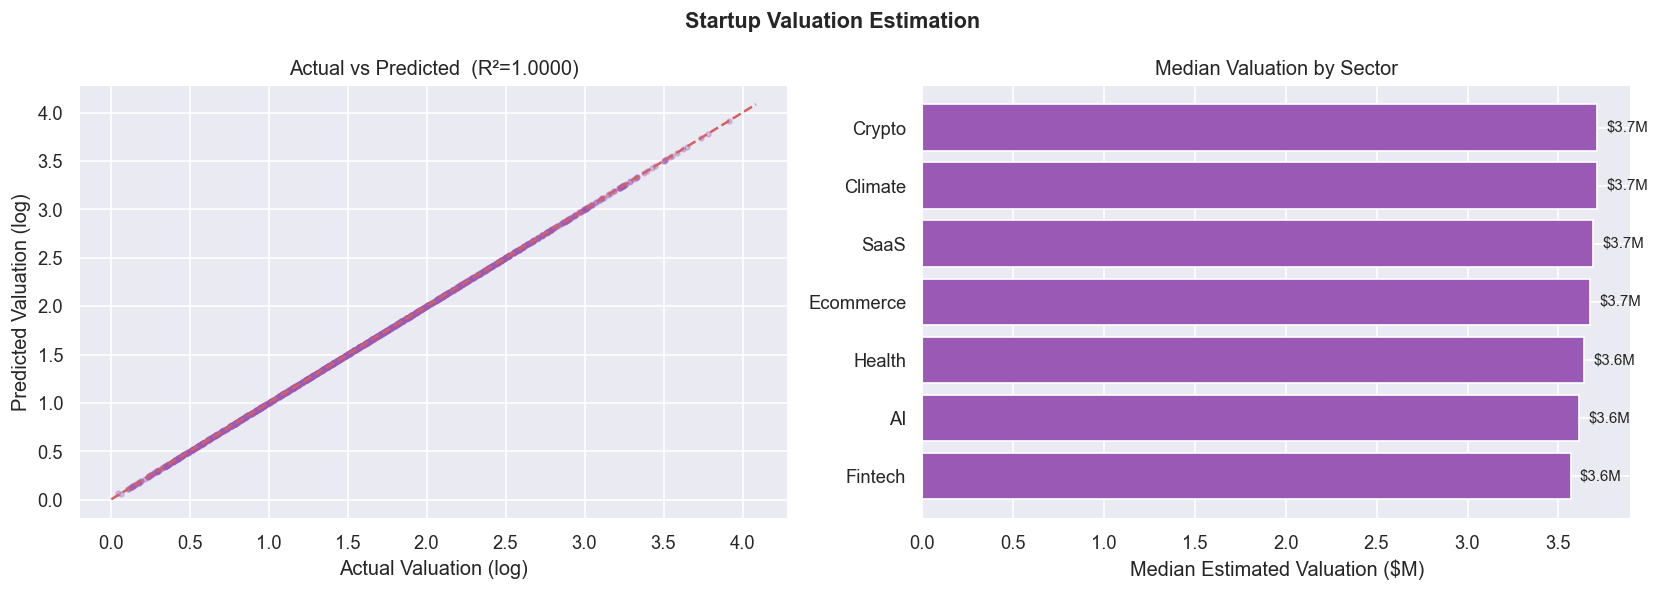

In [25]:
# Valuation by sector
df_fe['predicted_valuation_M'] = np.expm1(best_val_model.predict(X_scaled))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Startup Valuation Estimation', fontsize=13, fontweight='bold')

vp = val_results[best_val_name]['preds']
axes[0].scatter(yv_te.values[:1500], vp[:1500], alpha=0.3, s=8, color='#9b59b6')
mn, mx = yv_te.min(), yv_te.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
axes[0].set_xlabel('Actual Valuation (log)')
axes[0].set_ylabel('Predicted Valuation (log)')
axes[0].set_title(f'Actual vs Predicted  (R²={val_results[best_val_name]["r2"]:.4f})')

sector_val = df_fe.groupby('sector')['predicted_valuation_M'].median().sort_values(ascending=True)
axes[1].barh(sector_val.index, sector_val.values, color='#9b59b6', edgecolor='white')
axes[1].set_xlabel('Median Estimated Valuation ($M)')
axes[1].set_title('Median Valuation by Sector')
for i, v in enumerate(sector_val.values):
    axes[1].text(v + 0.05, i, f'${v:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## ⚠️ 12. Task 9 — Investor Risk Score

In [26]:
# Investor Risk Score = weighted combination of failure probability, burn risk, and 1/valuation
# We use the best outcome model for P(Failure)

failure_idx = list(le_outcome.classes_).index('Failure')

p_failure   = best_outcome_model.predict_proba(X_scaled)[:, failure_idx]
p_high_burn = best_burn_model.predict_proba(X_scaled)[:, 1]
val_norm    = (df_fe['predicted_valuation_M'] - df_fe['predicted_valuation_M'].min()) / \
              (df_fe['predicted_valuation_M'].max() - df_fe['predicted_valuation_M'].min())

# Risk = 0.5*P(Failure) + 0.3*P(HighBurn) + 0.2*(1-ValNorm)
df_fe['investor_risk_score'] = (
    0.50 * p_failure +
    0.30 * p_high_burn +
    0.20 * (1 - val_norm)
)

# Risk tiers
df_fe['risk_tier'] = pd.cut(df_fe['investor_risk_score'],
                             bins=[0, 0.3, 0.5, 0.7, 1.0],
                             labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk'])

print('Risk Tier Distribution:')
print(df_fe['risk_tier'].value_counts())

Risk Tier Distribution:
risk_tier
High Risk         42990
Moderate Risk     25418
Very High Risk    16065
Low Risk          15527
Name: count, dtype: int64


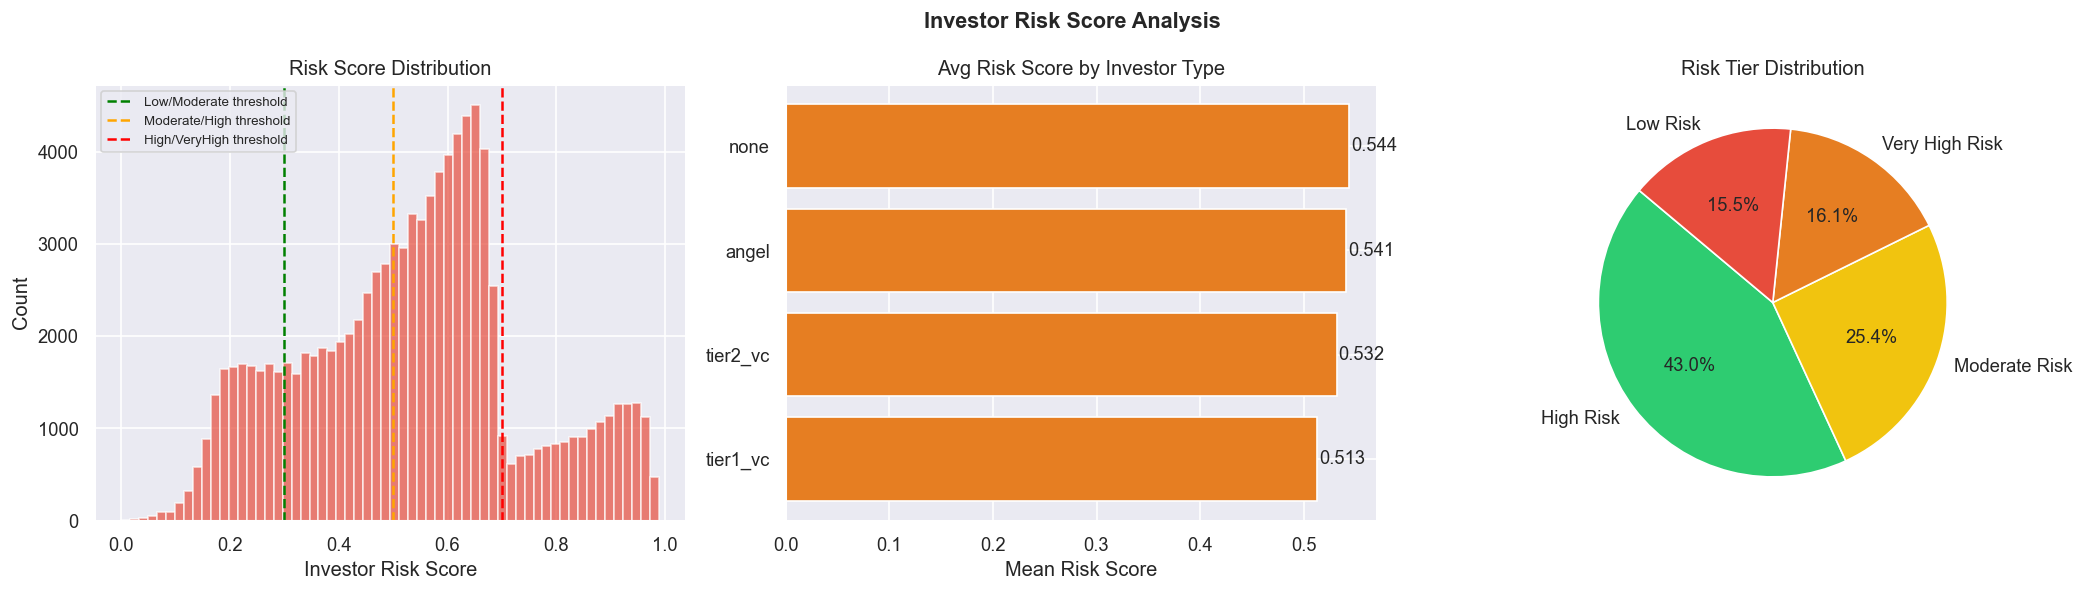

In [27]:
# Investor Risk Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Investor Risk Score Analysis', fontsize=13, fontweight='bold')

# Risk score distribution
axes[0].hist(df_fe['investor_risk_score'], bins=60, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Investor Risk Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Risk Score Distribution')
axes[0].axvline(0.3, color='green', linestyle='--', linewidth=1.5, label='Low/Moderate threshold')
axes[0].axvline(0.5, color='orange', linestyle='--', linewidth=1.5, label='Moderate/High threshold')
axes[0].axvline(0.7, color='red', linestyle='--', linewidth=1.5, label='High/VeryHigh threshold')
axes[0].legend(fontsize=8)

# Risk by investor type
inv_risk = df_fe.groupby('investor_type')['investor_risk_score'].mean().sort_values()
color_risk = ['#2ecc71' if v < 0.4 else '#e67e22' if v < 0.6 else '#e74c3c' for v in inv_risk]
axes[1].barh(inv_risk.index, inv_risk.values, color=color_risk, edgecolor='white')
for i, v in enumerate(inv_risk.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center')
axes[1].set_xlabel('Mean Risk Score')
axes[1].set_title('Avg Risk Score by Investor Type')

# Risk tier pie chart
tier_counts = df_fe['risk_tier'].value_counts()
tier_colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']
axes[2].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
            colors=tier_colors, startangle=140)
axes[2].set_title('Risk Tier Distribution')
plt.tight_layout()
plt.show()

## 📋 13. Comprehensive Model Performance Summary

In [28]:
summary_rows = []

for name, res in outcome_results.items():
    summary_rows.append({'Task': 'Outcome Classification', 'Model': name,
                         'Metric': 'ROC-AUC (OvR)', 'Score': round(res['roc_auc'], 4)})

for name, res in rev_results.items():
    summary_rows.append({'Task': 'Revenue Prediction', 'Model': name,
                         'Metric': 'R²', 'Score': round(res['r2'], 4)})

for name, res in burn_results.items():
    summary_rows.append({'Task': 'Burn Rate Risk', 'Model': name,
                         'Metric': 'ROC-AUC', 'Score': round(res['roc_auc'], 4)})

for name, res in fund_results.items():
    summary_rows.append({'Task': 'Funding Rounds', 'Model': name,
                         'Metric': 'R²', 'Score': round(res['r2'], 4)})

for name, res in acq_results.items():
    summary_rows.append({'Task': 'Acquisition Likelihood', 'Model': name,
                         'Metric': 'ROC-AUC', 'Score': round(res['roc_auc'], 4)})

for name, res in ipo_results.items():
    summary_rows.append({'Task': 'IPO Potential', 'Model': name,
                         'Metric': 'ROC-AUC', 'Score': round(res['roc_auc'], 4)})

for name, res in val_results.items():
    summary_rows.append({'Task': 'Valuation Estimation', 'Model': name,
                         'Metric': 'R²', 'Score': round(res['r2'], 4)})

summary_df = pd.DataFrame(summary_rows)
print('📊 COMPLETE MODEL PERFORMANCE SUMMARY')
print('='*65)
display(summary_df.style.background_gradient(cmap='RdYlGn', subset=['Score']))

📊 COMPLETE MODEL PERFORMANCE SUMMARY


,Task,Model,Metric,Score
0,Outcome Classification,Logistic Regression,ROC-AUC (OvR),0.871500
1,Outcome Classification,Random Forest,ROC-AUC (OvR),0.866100
2,Outcome Classification,XGBoost,ROC-AUC (OvR),0.867200
3,Outcome Classification,LightGBM,ROC-AUC (OvR),0.866600
4,Revenue Prediction,Ridge Regression,R²,1.000000
5,Revenue Prediction,Random Forest,R²,1.000000
6,Revenue Prediction,XGBoost,R²,0.999500
7,Revenue Prediction,LightGBM,R²,0.999400
8,Burn Rate Risk,Logistic Regression,ROC-AUC,1.000000
9,Burn Rate Risk,Random Forest,ROC-AUC,1.000000


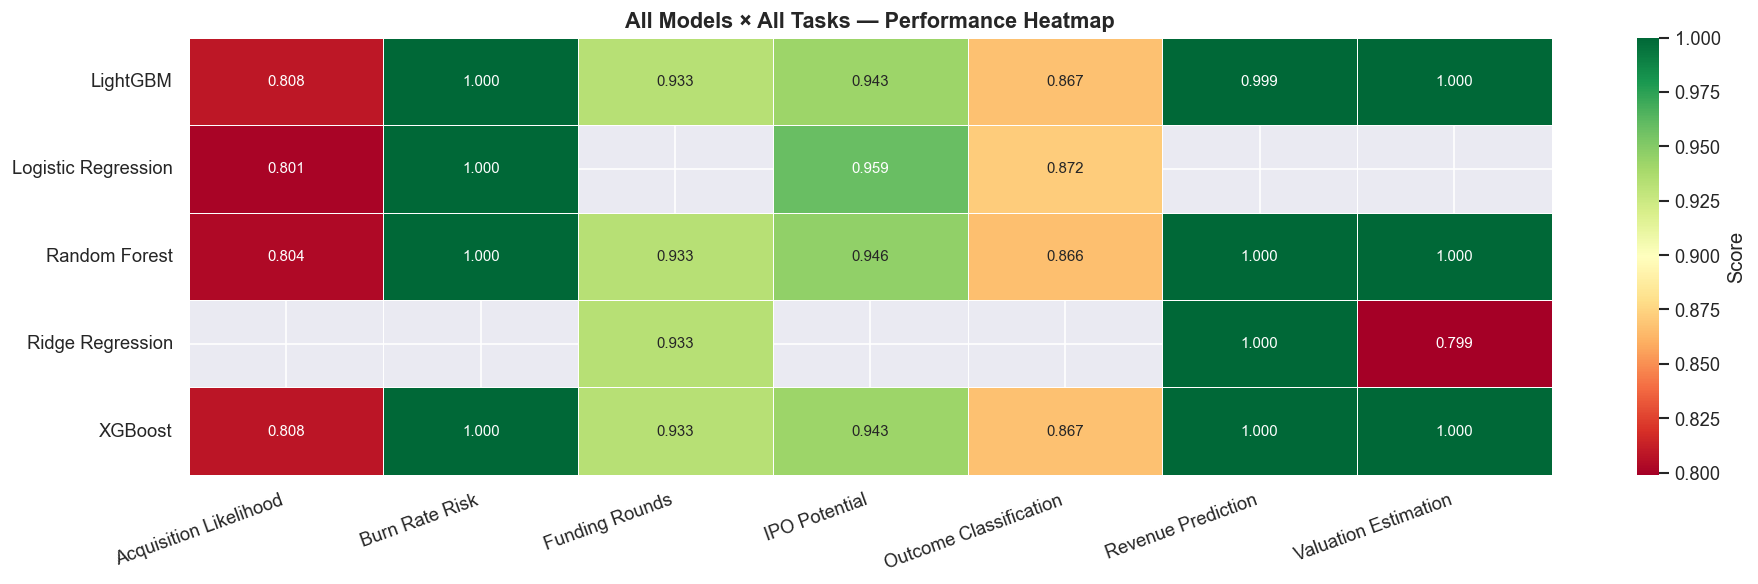

In [29]:
# Heatmap of all model scores per task
pivot = summary_df.pivot(index='Model', columns='Task', values='Score')

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Score'}, annot_kws={'size': 9})
ax.set_title('All Models × All Tasks — Performance Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 🔮 14. Single Startup Prediction — Inference Engine

In [30]:
def predict_startup(startup_dict):
    """
    Predict all metrics for a single startup.
    startup_dict keys: funding_rounds, founder_experience_years, team_size,
                       market_size_billion, product_traction_users, burn_rate_million,
                       revenue_million, investor_type, sector, founder_background
    """
    row = pd.DataFrame([startup_dict])

    # Encode categoricals
    for c in cat_cols:
        row[c + '_enc'] = le_dict[c].transform(row[c])

    # Feature engineering
    row['revenue_per_employee']  = row['revenue_million'] / (row['team_size'] + 1)
    row['burn_efficiency']       = row['revenue_million'] / (row['burn_rate_million'] + 0.01)
    row['traction_per_employee'] = row['product_traction_users'] / (row['team_size'] + 1)
    row['market_penetration']    = row['product_traction_users'] / (row['market_size_billion'] * 1e6 + 1)
    row['funding_per_round']     = row['burn_rate_million'] * 12 / (row['funding_rounds'] + 1)
    row['exp_team_ratio']        = row['founder_experience_years'] / (row['team_size'] + 1)
    row['revenue_to_market']     = row['revenue_million'] / (row['market_size_billion'] * 1e6 + 1)
    row['log_revenue']           = np.log1p(row['revenue_million'])
    row['log_traction']          = np.log1p(row['product_traction_users'])

    X_input = scaler.transform(row[BASE_FEATURES])

    # Predictions
    outcome_proba    = best_outcome_model.predict_proba(X_input)[0]
    predicted_class  = le_outcome.inverse_transform([outcome_proba.argmax()])[0]
    revenue_pred_log = best_rev_model.predict(X_input)[0]
    revenue_pred     = np.expm1(revenue_pred_log)
    burn_risk_proba  = best_burn_model.predict_proba(X_input)[0][1]
    fund_pred        = int(np.clip(round(best_fund_model.predict(X_input)[0]), 1, None))
    acq_prob         = best_acq_model.predict_proba(X_input)[0][1]
    ipo_prob         = best_ipo_model.predict_proba(X_input)[0][1]

    val_norm_val = 0.5  # placeholder normalized val
    risk_score = 0.5 * outcome_proba[list(le_outcome.classes_).index('Failure')] + \
                 0.3 * burn_risk_proba + 0.2 * (1 - val_norm_val)

    mult = MULTIPLE_MAP.get(startup_dict['investor_type'], 5)
    valuation_est = (startup_dict['revenue_million'] / 1e6) * mult

    print('=' * 55)
    print('  🚀 STARTUP PREDICTION REPORT')
    print('=' * 55)
    print(f'  Predicted Outcome      : {predicted_class}')
    print(f'  Outcome Probabilities  :')
    for cls, prob in zip(le_outcome.classes_, outcome_proba):
        bar = '█' * int(prob * 30)
        print(f'    {cls:15s}  {prob:.2%}  {bar}')
    print(f'  Revenue Prediction     : ${revenue_pred:,.0f}')
    print(f'  Burn Rate Risk         : {burn_risk_proba:.2%}  ({"HIGH" if burn_risk_proba > 0.5 else "LOW"})')
    print(f'  Predicted Funding Rnds : {fund_pred}')
    print(f'  Acquisition Likelihood : {acq_prob:.2%}')
    print(f'  IPO Potential Score    : {ipo_prob:.2%}')
    print(f'  Valuation Estimate     : ${valuation_est:.2f}M')
    print(f'  Investor Risk Score    : {risk_score:.3f}  ({"Low" if risk_score<0.3 else "Moderate" if risk_score<0.5 else "High" if risk_score<0.7 else "Very High"})')
    print('=' * 55)

    return {
        'predicted_outcome': predicted_class,
        'outcome_probabilities': dict(zip(le_outcome.classes_, outcome_proba.round(4))),
        'revenue_prediction': revenue_pred,
        'burn_rate_risk': round(burn_risk_proba, 4),
        'predicted_funding_rounds': fund_pred,
        'acquisition_likelihood': round(acq_prob, 4),
        'ipo_potential_score': round(ipo_prob, 4),
        'valuation_estimate_M': round(valuation_est, 2),
        'investor_risk_score': round(risk_score, 4)
    }


# --- Example Prediction ---
example_startup = {
    'funding_rounds':           3,
    'founder_experience_years': 10,
    'team_size':                45,
    'market_size_billion':      25.0,
    'product_traction_users':   500000,
    'burn_rate_million':        8.5,
    'revenue_million':          1200000,
    'investor_type':            'tier1_vc',
    'sector':                   'AI',
    'founder_background':       'ex_bigtech'
}

result = predict_startup(example_startup)

  🚀 STARTUP PREDICTION REPORT
  Predicted Outcome      : Acquisition
  Outcome Probabilities  :
    Acquisition      74.74%  ██████████████████████
    Failure          24.23%  ███████
    IPO              1.03%  
  Revenue Prediction     : $1,199,974
  Burn Rate Risk         : 0.21%  (LOW)
  Predicted Funding Rnds : 3
  Acquisition Likelihood : 77.00%
  IPO Potential Score    : 32.11%
  Valuation Estimate     : $18.00M
  Investor Risk Score    : 0.222  (Low)


## 💾 15. Save All Best Models

In [36]:
import os
os.makedirs('saved_models', exist_ok=True)

joblib.dump(best_outcome_model, 'saved_models/outcome_classifier.pkl')
joblib.dump(best_rev_model,     'saved_models/revenue_regressor.pkl')
joblib.dump(best_burn_model,    'saved_models/burn_risk_classifier.pkl')
joblib.dump(best_fund_model,    'saved_models/funding_rounds_regressor.pkl')
joblib.dump(best_acq_model,     'saved_models/acquisition_classifier.pkl')
joblib.dump(best_ipo_model,     'saved_models/ipo_classifier.pkl')
joblib.dump(best_val_model,     'saved_models/valuation_regressor.pkl', compress=9)
joblib.dump(scaler,             'saved_models/scaler.pkl')
joblib.dump(le_dict,            'saved_models/label_encoders.pkl')
joblib.dump(le_outcome,         'saved_models/outcome_label_encoder.pkl')

print('✅ All models saved to saved_models/')
print('Files:', os.listdir('saved_models'))

✅ All models saved to saved_models/
Files: ['.ipynb_checkpoints', 'acquisition_classifier.pkl', 'burn_risk_classifier.pkl', 'funding_rounds_regressor.pkl', 'ipo_classifier.pkl', 'label_encoders.pkl', 'outcome_classifier.pkl', 'outcome_label_encoder.pkl', 'revenue_regressor.pkl', 'scaler.pkl', 'valuation_regressor.pkl']
